In [ ]:
import sys, pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
sys.path.append(str(pathlib.Path().resolve() / "src"))

from core import (
    load_data, load_eye_data_for_subject, build_trials_table_for_subject, 
    merge_trials_with_df_idx, get_task_trials, apply_time_indexing, add_session_id_column,
    parse_target_columns, polar_to_cartesian, find_session_mat_files, load_sessions_v73,
    filter_mat_data_by_trials, add_response_metrics, add_memory_delay_features
)

from viz import (
    plot_eye_endpoints, plot_error_histogram, plot_error_vs_prev_diff, plot_error_variability_vs_delay
)

## 1. Dataset Overview  
- **Task design**: The *Delsac* task combines a delayed-saccade spatial working memory task with mapping of color/direction tuning.
  - On each trial, 6-8 brief random dot patterns with a given color and motion direction were shown. Different color/motion combinations were used for each stimulus and each trial. You can find the colors and motion directions of each stimulus pulse in each trial in trialInfo.delsac.mapColors and trialInfo.delsac.mapDirections, respectively.
  - On some sessions, 6 color/motion pulse stimuli were shown for 150 ms each, with a blank 50 ms interval between them (~1.2 s total)
  - On other sessions, 8 stimuli were shown for 100 ms each, with a blank 20 ms interval between them (~0.96 s total).

  - So there's 6-8 color/motion pulses (0.96–1.2s) → fixation delay (0.5s) → target presentation (0.1s) →  working memory delay (0.75 s) → saccade to remembered target.  

- **Data sources**:  
  - Neural dataset: 66 sessions (two files both in 0.025 s bin size, one containing 53 sessions, the other one 13 session) ---> 63 sessions of data 
  - Missing eye tracking data for the Session with this ID: ['110106']
  - Error loading eye tracking data for two other sessions
  - the sessions that are in v7.3 are the extra 13 sessions. Try converting the version back to v7.2 via Matlab.
  - v7.3 sessions take too long to load. you can comment out the corresponding functions and use onlt the 53 sessions. 

  - Behavioral dataset:
    - Paula sessions: v7.2=36, v7.3=7, total=43
    - Rex sessions:   v7.2=16, v7.3=4, total=20
    - 6001 samples × 4 channels × ~1307 trials per session(for all tasks, ~150 trials per session are for delsac). Channels: X position, Y position, pupil size, photodiode.

    - We matched neural data with corresponding behavioral data (eye-tracking data)
    - 4940 trials for subject Paula
    - 2607 trials for subject Rex 
---

## 2. Preprocessing Steps  
1. **Trial selection**  
   - data <--'all_data_siegel_0.025.pkl' 
   - filtered_delsac: filter data, keep only correct trials for delsac task, drop nan columns in 'trial' 
   - Each session of the eye trackig data has ~1500 trials. Of this we need ~150 trials of each, matching with neural and behavioral data of delsac task. 
   example for session '100706' : filtered_paula['100706']['ain'].shape --> (6001, 4, 124), 4 channels, 124 trials 
   - same for filtered_rex

2. **Feature Engineering**  
    - df_idx contains 7547 trials (all trials of 63 sessions of delsac task)

    **Time Indexing**
    - TIME_COLS_DEFAULT = [
      'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2',
      'stimOn', 'stimOff', 'targetOn', 'targetOff', 'fixptOff',
      'responseTime', 'responseDone', 'holdTgtOn', 'holdTgtOff',
      'responseHeld', 'outcomeTime'
      ]
    - Relative behavioral event times (e.g., fixation onset, target onset, response time) converted into eye-tracker sample indices using  
    [
      $ i = \text{round}\big((t - t_{\text{start}})\cdot f_s\big) = \text{round}\big((t+2.5)\cdot 1000\big) $
    ]
     with $ ( f_s = 1000\ \text{Hz} ) $.  (6001 samples per trial, relative time from stimulus onset = 0 [-2.5, 3.5] seconds)

    **Target Position**
    - "targetPos" --> "targEcc", "targAng", "targX", "targY"

    **Calculate Baseline Fixation, Predict Target and Response**
    - 'fixBaseX_raw', 'fixBaseY_raw', 'endX_raw',
       'endY_raw', 'targX_raw_pred', 'targY_raw_pred', 'endErr_raw'
    - Baseline position: average of 25 samples before go cue (25 ms)
    - Endpoint position: average of 20 samples centered on end-of-movement (20 ms)
    

In [2]:
data_path = "/home/aarghavan/nasShare/projects/labdul/Data_siegel/all_data_siegel_0.025.pkl"
data = load_data(data_path)

print(type(data))
if isinstance(data, dict):
    print(data.keys())
else:
    print(data)

<class 'dict'>
dict_keys(['trial', 'unit', 'session', 'spiketimes', 'trialsNeuron'])


In [3]:
extra_data_path = '/home/aarghavan/nasShare/projects/labdul/Data_siegel/new_13_sessions/all_tasks/all_new_13_tasks.pkl'
extra_data = load_data(extra_data_path)

In [4]:
# both datasets have 239 bins per channel

print(len(extra_data['spikecounts'][0][0][0]))
print(len(data['spiketimes'][0][0][0]))


239
239


In [5]:
# Merge the two datasets 
# regarding key names and column names of the two datasets: 'spikecounts', 'trialsNeuron' match, 'session' formats does not match 

print(extra_data.keys())
print(data.keys())

# Check key alignment
print("extra_data keys:", extra_data.keys())
print("data keys:", data.keys())

# Rename for consistency
extra_data_renamed = extra_data.copy()

# Check if other keys match
common_keys = set(data.keys()) & set(extra_data.keys())
print("Common keys:", common_keys)
# Output: {'trial', 'unit', 'session', 'trialsNeuron'}

# Merge strategy:
# 1. Keep 'spiketimes' and 'spikecounts' separate (different data formats)
# 2. Merge on common keys: 'trial', 'unit', 'session', 'trialsNeuron'

# Example merge approach:
merged_data = {
    'trial': data['trial'] + extra_data['trial'],  # concatenate trial lists
    'unit': data['unit'] + extra_data['unit'],      # concatenate unit lists
    'session': data['session'] + extra_data['session'],  # concatenate sessions
    'spiketimes': data['spiketimes'] + extra_data_renamed['spikecounts'],
    'trialsNeuron': data['trialsNeuron'] + extra_data['trialsNeuron'],
}

print(f"Original data trials: {len(data['trial'])}")
print(f"Extra data trials: {len(extra_data['trial'])}")
print(f"Merged data trials: {len(merged_data['trial'])}")


# merged_data = data  # if you want to use only the 53 sessions dataset for now uncomment this line and comment out the merge above

dict_keys(['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron'])
dict_keys(['trial', 'unit', 'session', 'spiketimes', 'trialsNeuron'])
extra_data keys: dict_keys(['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron'])
data keys: dict_keys(['trial', 'unit', 'session', 'spiketimes', 'trialsNeuron'])
Common keys: {'session', 'trialsNeuron', 'trial', 'unit'}
Original data trials: 53
Extra data trials: 13
Merged data trials: 66


In [6]:
print(extra_data.keys())
print(data.keys())
print(merged_data.keys())

dict_keys(['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron'])
dict_keys(['trial', 'unit', 'session', 'spiketimes', 'trialsNeuron'])
dict_keys(['trial', 'unit', 'session', 'spiketimes', 'trialsNeuron'])


In [7]:
# the excel file received from scott, it contains session info from all 65 sessions

data_path = "/home/aarghavan/aslan/mocol_sessionTable_processed.xlsx"
sessionTable = pd.read_excel(data_path)
sessionTable[['session', 'subject']]

,session,subject
0,100706,paula
1,100724,paula
2,100725,paula
3,100726,paula
4,100730,paula
...,...,...
61,110215,rex
62,110216,rex
63,110218,rex
64,110219,rex


In [8]:
# filter data, keep only correct trials in delsac, drop nan columns 
filtered_delsac = get_task_trials(merged_data, only_correct=True)
filtered_delsac[0]['delsac'].columns

Index(['trial', 'taskTrial', 'bhvTrial', 'condition', 'task', 'outcome',
       'correct', 'reactionTime', 'numRewards', 'mapColors', 'mapDirections',
       'targetPos', 'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2',
       'stimOn', 'stimOff', 'targetOn', 'targetOff', 'fixptOff',
       'responseTime', 'responseDone', 'holdTgtOn', 'holdTgtOff',
       'responseHeld', 'outcomeTime', 'rewardOn', 'rewardOff', 'trialEnd',
       'session', 'trialRefTimes', 'badTimingTrials', 'badTrials'],
      dtype='object')

In [9]:
filtered_delsac[0]['delsac'][['holdTgtOn', 'holdTgtOff', 'responseHeld', 'outcomeTime']]

,holdTgtOn,holdTgtOff,responseHeld,outcomeTime
[100725.3],2.759800,3.509825,3.504375,3.504375
[100725.5],2.769875,3.519800,3.514500,3.514500
[100725.6],2.779825,3.529825,3.524325,3.524325
[100725.7],2.689825,3.439800,3.434250,3.434250
[100725.8],2.819800,3.569775,3.564100,3.564100
...,...,...,...,...
[100725.216],2.799825,3.549775,3.543950,3.543950
[100725.217],2.739825,3.489825,3.484150,3.484150
[100725.219],2.759850,3.509800,3.504525,3.504525
[100725.224],2.759825,3.509800,3.504200,3.504200


In [10]:
df_idx = apply_time_indexing(filtered_delsac, task_key="delsac") # here the time indices could be above 6000, escpecially in these columns --> 'holdTgtOff', 'responseHeld', 'outcomeTime'

print(len(df_idx))
df_idx.head()
df_idx.columns

7742


Index(['trial', 'taskTrial', 'bhvTrial', 'condition', 'task', 'outcome',
       'correct', 'reactionTime', 'numRewards', 'mapColors', 'mapDirections',
       'targetPos', 'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2',
       'stimOn', 'stimOff', 'targetOn', 'targetOff', 'fixptOff',
       'responseTime', 'responseDone', 'holdTgtOn', 'holdTgtOff',
       'responseHeld', 'outcomeTime', 'rewardOn', 'rewardOff', 'trialEnd',
       'session', 'trialRefTimes', 'badTimingTrials', 'badTrials',
       'trialStart_idx', 'fixptOn_idx', 'fixationTime_idx', 'fixptOn2_idx',
       'stimOn_idx', 'stimOff_idx', 'targetOn_idx', 'targetOff_idx',
       'fixptOff_idx', 'responseTime_idx', 'responseDone_idx', 'holdTgtOn_idx',
       'holdTgtOff_idx', 'responseHeld_idx', 'outcomeTime_idx'],
      dtype='object')

In [11]:
# Add clean session IDs
df_idx = add_session_id_column(df_idx, source_col="session")
df_idx["session_id"].nunique()

66

In [12]:
len(df_idx[df_idx['session_id']== '110106']) # 48 trials is session 110106, the session that has missing eye data

48

In [13]:
# 1) Parse targetPos -> targEcc, targAng (normalized to (-180, 180])
df_idx = parse_target_columns(df_idx, source_col="targetPos", ecc_col="targEcc", ang_col="targAng")

# 2) Polar → Cartesian
df_idx = polar_to_cartesian(df_idx, ecc_col="targEcc", ang_col="targAng", x_col="targX", y_col="targY")

# quick peek
df_idx[["targetPos", "targEcc", "targAng", "targX", "targY"]]

,targetPos,targEcc,targAng,targX,targY
[100725.3],"(6, 180)",6.0,180.0,-6.0,7.347881e-16
[100725.6],"(6, 300)",6.0,-60.0,3.0,-5.196152e+00
[100725.7],"(6, 0)",6.0,0.0,6.0,0.000000e+00
[100725.8],"(6, 240)",6.0,-120.0,-3.0,-5.196152e+00
[100725.9],"(6, 300)",6.0,-60.0,3.0,-5.196152e+00
...,...,...,...,...,...
127,"[6, 60]",6.0,60.0,3.0,5.196152e+00
128,"[6, 300]",6.0,-60.0,3.0,-5.196152e+00
131,"[6, 240]",6.0,-120.0,-3.0,-5.196152e+00
132,"[6, 0]",6.0,0.0,6.0,0.000000e+00


SHUFFLE

In [14]:
# cols_to_shuffle = ["targetPos", "targEcc", "targAng", "targX", "targY", 'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2',
#        'stimOn', 'stimOff', 'targetOn', 'targetOff', 'fixptOff',
#        'responseTime', 'responseDone', 'holdTgtOn', 'holdTgtOff',
#        'responseHeld', 'outcomeTime', 'rewardOn', 'rewardOff', 'trialEnd']
# shuffled_vals = df_idx[cols_to_shuffle].sample(frac=1, random_state=42).reset_index(drop=True)
# shuffled_vals = shuffled_vals.sample(frac=1, random_state=42).reset_index(drop=True)
# df_idx[cols_to_shuffle] = shuffled_vals.values

In [15]:
paula_sessions = sessionTable[sessionTable['subject'].str.lower() == 'paula']['session'].tolist()
rex_sessions = sessionTable[sessionTable['subject'].str.lower() == 'rex']['session'].tolist()
session_subject_df = sessionTable[['session', 'subject']]


display(session_subject_df)

print("Paula sessions:", paula_sessions)
print("Count:", len(paula_sessions))
print("Rex sessions:", rex_sessions)
print("Count:", len(rex_sessions))


# sessionTable[['session', 'subject']]

,session,subject
0,100706,paula
1,100724,paula
2,100725,paula
3,100726,paula
4,100730,paula
...,...,...
61,110215,rex
62,110216,rex
63,110218,rex
64,110219,rex


Paula sessions: ['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', '101128', '101202', '101206', '101207', '101209', '101210', '101216', '110106', '110107_01', '110107_02', '110110_01', '110110_02', '110111_01', '110111_02', '110112_01', '110112_02', '110115_01', '110115_02', '110116_01', '110116_02', '110117_01', '110117_02']
Count: 44
Rex sessions: ['100907', '100910', '100913', '100915', '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', '110121', '110214', '110215', '110216', '110218', '110219', '110220']
Count: 22


In [16]:
EYE_DIR = "/home/aarghavan/nasShare/projects/labdul/Data_siegel/eyetracker_data"

# (nMapStim == 6) | (nMapStim == 8) --> 52 sessions
v72_sessions = [
    '100706', '100819', '100917', '101123', '110107_02',
    '100724', '100820', '100920', '101124', '110110_01', 
    '100725', '100823', '100921', '101127', '110110_02', '110120',
    '100726', '100824', '101008', '101128', '110111_01', '110121',
    '100730', '100826', '101009', '101202', '110111_02',
    '100731', '100827', '101023', '101206',  
    '100802', '100828', '101024', '101207', 
    '100803', '100907', '101027', '101209', '110115_01',
    '100804', '100910', '101028', '101210',
    '100817', '100913', '101030', '101216', 
    '100818', '100915', '101122', '110107_01',
]

# (nMapStim == 6) --> 45 sessions
# v72_sessions = [
#     '100706', '100819', '100917', '101123',
#     '100724', '100820', '100920', '101124', 
#     '100725', '100823', '100921', '101127', '110120',
#     '100726', '100824', '101008', '101128', '110121',
#     '100730', '100826', '101009', '101202',
#     '100731', '100827', '101023', '101206',  
#     '100802', '100828', '101024', '101207', 
#     '100803', '100907', '101027', '101209',
#     '100804', '100910', '101028', '101210',
#     '100817', '100913', '101030', '101216', 
#     '100818', '100915', '101122',
# ]

# extra_sessions --> 13 sessions, error in loading '110214', '110215'
v73_sessions = [
    '110112_01', '110112_02', '110115_02', '110116_01',
    '110116_02', '110117_01', '110117_02','110214',
    '110215', '110216', '110218', '110219', '110220']

# test
# v73_sessions = [
#     '110112_01']

v72_sessions_paula = session_subject_df[
    (session_subject_df['session'].isin(v72_sessions)) & 
    (session_subject_df['subject'].str.lower() == 'paula')
]['session'].tolist()

v72_sessions_rex = session_subject_df[
    (session_subject_df['session'].isin(v72_sessions)) & 
    (session_subject_df['subject'].str.lower() == 'rex')
]['session'].tolist()


v73_sessions_paula = session_subject_df[
    (session_subject_df['session'].isin(v73_sessions)) & 
    (session_subject_df['subject'].str.lower() == 'paula')
]['session'].tolist()

v73_sessions_rex = session_subject_df[
    (session_subject_df['session'].isin(v73_sessions)) & 
    (session_subject_df['subject'].str.lower() == 'rex')
]['session'].tolist()

print(v73_sessions_paula)
print(v73_sessions_rex)


['110112_01', '110112_02', '110115_02', '110116_01', '110116_02', '110117_01', '110117_02']
['110214', '110215', '110216', '110218', '110219', '110220']


In [17]:
mat_data_v73_paula = load_sessions_v73(v73_sessions_paula)

# Check format
for session_id, data in mat_data_v73_paula.items():
    print(f"{session_id}: {data['ain'].shape}")

✓ Loaded 110112_01: ain shape (6001, 4, 1368)
✓ Loaded 110112_02: ain shape (6001, 4, 1558)
✓ Loaded 110115_02: ain shape (6001, 4, 1159)
✓ Loaded 110116_01: ain shape (6001, 4, 1359)
✓ Loaded 110116_02: ain shape (6001, 4, 1603)
✓ Loaded 110117_01: ain shape (6001, 4, 1212)
✓ Loaded 110117_02: ain shape (6001, 4, 1336)
110112_01: (6001, 4, 1368)
110112_02: (6001, 4, 1558)
110115_02: (6001, 4, 1159)
110116_01: (6001, 4, 1359)
110116_02: (6001, 4, 1603)
110117_01: (6001, 4, 1212)
110117_02: (6001, 4, 1336)


In [18]:
mat_data_v73_rex = load_sessions_v73(v73_sessions_rex)

# Check format
for session_id, data in mat_data_v73_rex.items():
    print(f"{session_id}: {data['ain'].shape}")

✗ Error loading 110214: Unable to get group info (bad symbol table node signature)
✗ Error loading 110215: Unable to synchronously open file (truncated file: eof = 8110004066, sblock->base_addr = 512, stored_eof = 14018941798)
✓ Loaded 110216: ain shape (6001, 4, 1487)
✓ Loaded 110218: ain shape (6001, 4, 1338)
✓ Loaded 110219: ain shape (6001, 4, 1153)
✓ Loaded 110220: ain shape (6001, 4, 1124)
110216: (6001, 4, 1487)
110218: (6001, 4, 1338)
110219: (6001, 4, 1153)
110220: (6001, 4, 1124)


In [19]:
mat_data_v73_paula.keys()

dict_keys(['110112_01', '110112_02', '110115_02', '110116_01', '110116_02', '110117_01', '110117_02'])

In [20]:
# Paula
mat_data_paula, missing_paula, total_paula = load_eye_data_for_subject(EYE_DIR, v72_sessions_paula)
print(f"Loaded Paula sessions: {len(mat_data_paula)}  | Missing: {missing_paula}")
print(f"Total trials for Paula: {total_paula:,}")

# Rex
mat_data_rex, missing_rex, total_rex = load_eye_data_for_subject(EYE_DIR, v72_sessions_rex)
print(f"Loaded Rex sessions:   {len(mat_data_rex)}  | Missing: {missing_rex}")
print(f"Total trials for Rex:  {total_rex:,}")

Loaded Paula sessions: 36  | Missing: []
Total trials for Paula: 52,002
Loaded Rex sessions:   16  | Missing: []
Total trials for Rex:  21,972


In [21]:
mat_data_paula['100725']['ain'].shape

(6001, 4, 1307)

In [22]:
# Merge v7.2 and v7.3 data for both subjects
mat_data_paula = {**mat_data_paula, **mat_data_v73_paula}
mat_data_rex = {**mat_data_rex, **mat_data_v73_rex}

# Verify merge
print(f"Paula sessions: v7.2={len(mat_data_paula) - len(mat_data_v73_paula)}, v7.3={len(mat_data_v73_paula)}, total={len(mat_data_paula)}")
print(f"Rex sessions:   v7.2={len(mat_data_rex) - len(mat_data_v73_rex)}, v7.3={len(mat_data_v73_rex)}, total={len(mat_data_rex)}")

# Check samples
print(f"\nPaula sample: {mat_data_paula['100725']['ain'].shape}")
# print(f"Paula v7.3 sample: {mat_data_v73_paula['110112_01']['ain'].shape}")

Paula sessions: v7.2=36, v7.3=7, total=43
Rex sessions:   v7.2=16, v7.3=4, total=20

Paula sample: (6001, 4, 1307)


In [23]:
# Paula
filtered_paula, summary_paula = filter_mat_data_by_trials(df_idx, mat_data_paula, ain_key="ain", schema_key="ainSchema")
display(summary_paula.head())

# Rex
filtered_rex, summary_rex = filter_mat_data_by_trials(df_idx, mat_data_rex, ain_key="ain", schema_key="ainSchema")
display(summary_rex.head())

# Example: inspect a session
sid = next(iter(filtered_paula.keys()))
print(sid, filtered_paula[sid]["ain"].shape, filtered_paula[sid]["kept_trial_ids"][:10])


,session_id,trials_total,trials_kept
0,100706,1300,124
1,100724,1373,139
2,100725,1307,141
3,100726,876,140
4,100730,1231,142


,session_id,trials_total,trials_kept
0,100907,1043,143
1,100910,1611,147
2,100913,1557,146
3,100915,1593,138
4,100917,1531,139


100706 (6001, 4, 124) [ 2  3  4  5  9 10 11 12 14 15]


In [24]:
# # Inspect v7.3 schema
# print("V7.3 ainSchema type:", type(mat_data_v73_paula['110112_01']['ainSchema']))
# print("V7.3 ainSchema shape:", mat_data_v73_paula['110112_01']['ainSchema'])
# print("V7.3 ainSchema dtype:", mat_data_v73_paula['110112_01']['ainSchema'])
# print("V7.3 ainSchema content:\n", mat_data_v73_paula['110112_01']['ainSchema'])

# # Compare with v7.2
# print("\n---\nV7.2 ainSchema type:", type(mat_data_paula['100725']['ainSchema']))
# print("V7.2 ainSchema shape:", mat_data_paula['100725']['ainSchema'].shape)
# print("V7.2 ainSchema dtype:", mat_data_paula['100725']['ainSchema'].dtype)
# print("V7.2 ainSchema content:\n", mat_data_paula['100725']['ainSchema'])

In [25]:
print(summary_paula['trials_kept'].sum())
print(summary_rex['trials_kept'].sum())
print(summary_paula['trials_kept'].sum() + summary_rex['trials_kept'].sum())

4940
2607
7547


# Calculate Base line fixation point 

In [26]:
df_trials_paula, fit_paula = build_trials_table_for_subject(filtered_paula, df_idx)
df_trials_rex,   fit_rex   = build_trials_table_for_subject(filtered_rex,   df_idx)

In [27]:
df_trials_paula[df_trials_paula["session_id"] == "100725"].head()

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX,targY,correct,responseTime_idx,responseDone_idx,fixptOff_idx,targX_raw_pred,targY_raw_pred,endErr_raw
263,100725,3,-5007.72,-15099.16,-2152.428571,-15311.428571,-6.0,7.347881e-16,1,5242.0,5250.0,5050.0,-1941.279039,-15166.874830,255.890424
264,100725,6,-5094.92,-14996.80,-6841.238095,-13387.857143,3.0,-5.196152e+00,1,5258.0,5267.0,5050.0,-6726.799021,-13113.079146,297.656260
265,100725,7,-4941.64,-14994.72,-7812.285714,-14835.523810,6.0,0.000000e+00,1,5175.0,5183.0,5050.0,-8008.080961,-14927.005170,216.112512
266,100725,8,-5069.48,-15079.68,-3710.809524,-13327.761905,-3.0,-5.196152e+00,1,5301.0,5309.0,5050.0,-3634.918061,-13263.673976,99.331650
267,100725,9,-4975.84,-15087.40,-6928.761905,-13329.523810,3.0,-5.196152e+00,1,5311.0,5323.0,5050.0,-6607.719021,-13203.679146,344.826641


In [28]:
merged_paula = merge_trials_with_df_idx(
    df_trials=df_trials_paula,
    df_idx=df_idx,
    trial_id_col="trial_id",
    trial_col="trial",
    session_col="session_id",
)

# Rex
merged_rex = merge_trials_with_df_idx(
    df_trials=df_trials_rex,
    df_idx=df_idx,
    trial_id_col="trial_id",
    trial_col="trial",
    session_col="session_id",
)

In [29]:
merged_paula

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,responseTime_idx,responseDone_idx,holdTgtOn_idx,holdTgtOff_idx,responseHeld_idx,outcomeTime_idx,targEcc,targAng,targX,targY
[100706.2],100706,2,10218.32,-6506.60,7323.571429,-6579.285714,7078.318084,-6412.870771,296.383428,2,...,5272.0,5274.0,5280.0,6030.0,6024.0,6024.0,6.0,0.0,6.0,0.000000e+00
[100706.3],100706,3,10188.56,-6520.56,13730.428571,-6740.809524,13328.561916,-6614.289229,421.312466,3,...,5298.0,5310.0,5320.0,6070.0,6064.0,6064.0,6.0,180.0,-6.0,7.347881e-16
[100706.4],100706,4,10190.00,-6554.28,11380.904762,-8739.285714,11706.865295,-8635.116206,342.201046,4,...,5336.0,5348.0,5360.0,6110.0,6104.0,6104.0,6.0,120.0,-3.0,5.196152e+00
[100706.5],100706,5,10175.68,-6522.44,11400.333333,-8611.190476,11692.545295,-8603.276206,292.319117,5,...,5322.0,5334.0,5340.0,6090.0,6085.0,6085.0,6.0,120.0,-3.0,5.196152e+00
[100706.9],100706,9,10188.56,-6470.00,9282.190476,-8934.571429,8565.423379,-8457.106976,861.235957,9,...,5444.0,5456.0,5460.0,6210.0,6204.0,6204.0,6.0,60.0,3.0,5.196152e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,110117_02,293,2377.64,-4072.28,-1247.047619,-2479.952381,677.125856,-2359.891038,1927.915529,293,...,5017.0,5030.0,5040.0,5790.0,5785.0,5785.0,6.0,-60.0,3.0,-5.196152e+00
121,110117_02,297,2192.44,-4099.12,3621.666667,-5863.190476,3892.954144,-5811.508962,276.166389,297,...,4858.0,4861.0,4870.0,5620.0,5615.0,5615.0,6.0,120.0,-3.0,5.196152e+00
126,110117_02,302,2376.32,-4119.48,-211.571429,-2553.857143,675.805856,-2407.091038,899.432452,302,...,4982.0,4990.0,5000.0,5750.0,5744.0,5744.0,6.0,-60.0,3.0,-5.196152e+00
127,110117_02,303,2193.64,-4273.16,-35.047619,-2830.380952,493.125856,-2560.771038,593.006514,303,...,5030.0,5038.0,5050.0,5800.0,5794.0,5794.0,6.0,-60.0,3.0,-5.196152e+00


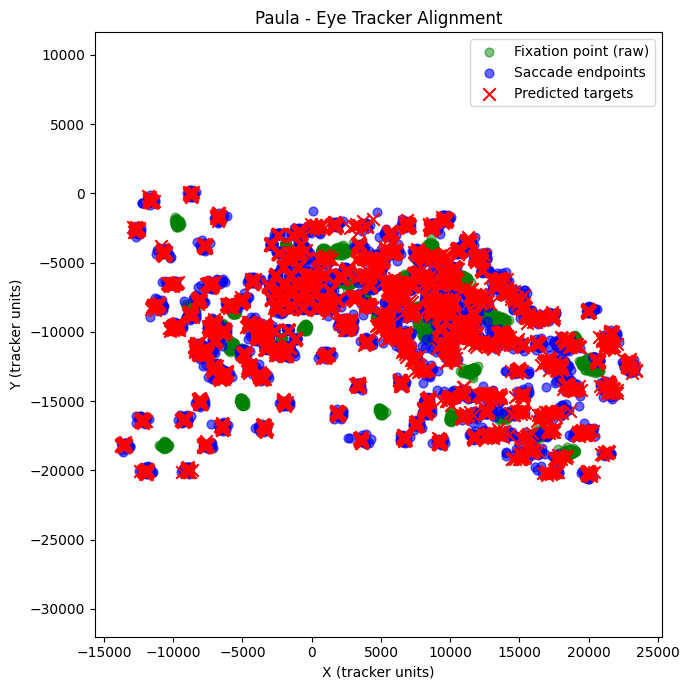

In [30]:
# Paula
plot_eye_endpoints(merged_paula, title="Paula - Eye Tracker Alignment")

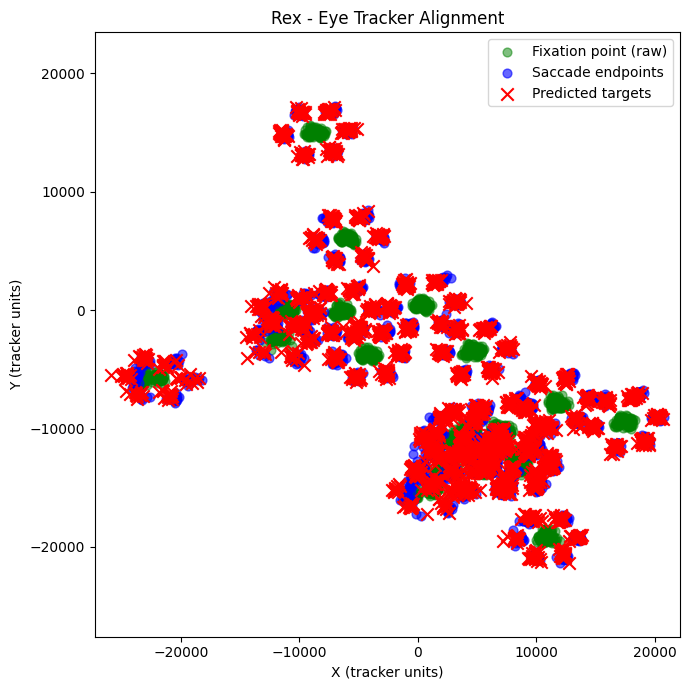

In [31]:
# Rex
plot_eye_endpoints(merged_rex, title="Rex - Eye Tracker Alignment")

In [32]:
merged_paula_with_resp, fit_paula_resp = add_response_metrics(merged_paula)
merged_rex_with_resp,   fit_rex_resp   = add_response_metrics(merged_rex)

In [33]:
merged_rex_with_resp

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,targEcc,targAng,targX,targY,respEcc_raw,respAng_raw,respX_dva,respY_dva,respEcc_dva,respAng_dva
0,100907,978,11842.28,-7591.96,11270.809524,-10435.142857,10730.379759,-9692.071375,918.814213,978,...,6.0,60.0,3.0,5.196152,2900.046080,-101.364834,2.175867,7.341261,7.656926,73.490774
1,100907,979,11978.76,-7815.72,11363.523810,-9874.000000,10866.859759,-9915.831375,498.422555,979,...,6.0,60.0,3.0,5.196152,2148.262584,-106.641822,1.982109,5.248435,5.610243,69.310598
2,100907,984,12373.48,-7860.80,11155.857143,-9708.904762,11261.579759,-9960.911375,273.284841,984,...,6.0,60.0,3.0,5.196152,2213.164394,-123.378869,3.122891,4.494119,5.472619,55.205186
3,100907,985,12465.80,-7980.40,11569.571429,-9570.857143,11353.899759,-10080.511375,553.409166,985,...,6.0,60.0,3.0,5.196152,1825.590199,-119.401423,2.381328,3.917370,4.584377,58.705026
4,100907,993,11933.32,-8085.92,11203.095238,-9912.047619,10821.419759,-10186.031375,469.833237,993,...,6.0,60.0,3.0,5.196152,1966.715608,-111.795289,2.130846,4.595935,5.065878,65.125808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2602,110220,1407,2651.16,-15878.88,-783.272727,-15824.818182,775.890518,-17254.224579,2115.228752,1407,...,6.0,60.0,3.0,5.196152,3434.858198,179.098175,6.596611,0.440190,6.611281,3.817668
2603,110220,1408,1494.12,-15190.60,-373.333333,-14651.761905,270.686629,-13653.892220,1187.647094,1408,...,6.0,-60.0,3.0,-5.196152,1943.637941,163.904945,3.805129,-1.557759,4.111644,-22.263415
2604,110220,1413,1599.04,-15295.40,3359.666667,-13911.333333,3474.309482,-13920.055421,114.974127,1413,...,6.0,-120.0,-3.0,-5.196152,2239.519323,38.171653,-2.776839,-5.205861,5.900154,-118.075739
2605,110220,1414,1165.92,-15291.48,-1706.095238,-15181.904762,-1932.782853,-15130.116799,232.527993,1414,...,6.0,0.0,6.0,0.000000,2874.104776,177.815069,5.543936,0.141045,5.545730,1.457369


In [34]:
paula_df = add_memory_delay_features(merged_paula_with_resp)

rex_df = add_memory_delay_features(merged_rex_with_resp)

In [35]:
paula_df[["memoryDelay","curr","prev","diff","err", "folded_err"]]

,memoryDelay,curr,prev,diff,err,folded_err
0,0.749975,0.0,NaN,NaN,-4.205191,4.205191
1,0.750025,180.0,0.0,180.0,2.471326,-2.471326
2,0.750025,120.0,180.0,60.0,6.525877,-6.525877
3,0.750000,120.0,120.0,0.0,5.003106,5.003106
4,0.750000,60.0,120.0,60.0,-15.815104,15.815104
...,...,...,...,...,...,...
4935,0.749975,-60.0,-60.0,0.0,-23.887401,-23.887401
4936,0.750025,120.0,-60.0,180.0,5.153200,-5.153200
4937,0.750025,-60.0,120.0,180.0,-14.630587,14.630587
4938,0.750025,-60.0,-60.0,0.0,-12.621620,-12.621620


In [36]:
rex_df[["memoryDelay","curr","prev","diff","err", "folded_err"]]

,memoryDelay,curr,prev,diff,err,folded_err
0,0.750000,60.0,NaN,NaN,-13.490774,13.490774
1,0.750025,60.0,60.0,0.0,-9.310598,-9.310598
2,0.750025,60.0,60.0,0.0,4.794814,4.794814
3,0.750025,60.0,60.0,0.0,1.294974,1.294974
4,0.750000,60.0,60.0,0.0,-5.125808,-5.125808
...,...,...,...,...,...,...
2602,0.750000,60.0,120.0,60.0,56.182332,-56.182332
2603,0.750025,-60.0,60.0,120.0,-37.736585,37.736585
2604,0.750025,-120.0,-60.0,60.0,-1.924261,1.924261
2605,0.750000,0.0,-120.0,120.0,-1.457369,-1.457369


In [37]:
paula_df['abs_err'] = paula_df['err'].abs()
rex_df['abs_err'] = rex_df['err'].abs()

In [38]:
paula_df

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,memoryDelay,curr,resp,prev,diff_signed,diff_abs,err,folded_err,diff,abs_err
0,100706,2,10218.32,-6506.60,7323.571429,-6579.285714,7078.318084,-6412.870771,296.383428,2,...,0.749975,0.0,4.205191,NaN,NaN,NaN,-4.205191,4.205191,NaN,4.205191
1,100706,3,10188.56,-6520.56,13730.428571,-6740.809524,13328.561916,-6614.289229,421.312466,3,...,0.750025,180.0,177.528674,0.0,-180.0,180.0,2.471326,-2.471326,180.0,2.471326
2,100706,4,10190.00,-6554.28,11380.904762,-8739.285714,11706.865295,-8635.116206,342.201046,4,...,0.750025,120.0,113.474123,180.0,-60.0,60.0,6.525877,-6.525877,60.0,6.525877
3,100706,5,10175.68,-6522.44,11400.333333,-8611.190476,11692.545295,-8603.276206,292.319117,5,...,0.750000,120.0,114.996894,120.0,0.0,0.0,5.003106,5.003106,0.0,5.003106
4,100706,9,10188.56,-6470.00,9282.190476,-8934.571429,8565.423379,-8457.106976,861.235957,9,...,0.750000,60.0,75.815104,120.0,-60.0,60.0,-15.815104,15.815104,60.0,15.815104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4935,110117_02,293,2377.64,-4072.28,-1247.047619,-2479.952381,677.125856,-2359.891038,1927.915529,293,...,0.749975,-60.0,-36.112599,-60.0,0.0,0.0,-23.887401,-23.887401,0.0,23.887401
4936,110117_02,297,2192.44,-4099.12,3621.666667,-5863.190476,3892.954144,-5811.508962,276.166389,297,...,0.750025,120.0,114.846800,-60.0,-180.0,180.0,5.153200,-5.153200,180.0,5.153200
4937,110117_02,302,2376.32,-4119.48,-211.571429,-2553.857143,675.805856,-2407.091038,899.432452,302,...,0.750025,-60.0,-45.369413,120.0,-180.0,180.0,-14.630587,14.630587,180.0,14.630587
4938,110117_02,303,2193.64,-4273.16,-35.047619,-2830.380952,493.125856,-2560.771038,593.006514,303,...,0.750025,-60.0,-47.378380,-60.0,0.0,0.0,-12.621620,-12.621620,0.0,12.621620


In [39]:
rex_df

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,memoryDelay,curr,resp,prev,diff_signed,diff_abs,err,folded_err,diff,abs_err
0,100907,978,11842.28,-7591.96,11270.809524,-10435.142857,10730.379759,-9692.071375,918.814213,978,...,0.750000,60.0,73.490774,NaN,NaN,NaN,-13.490774,13.490774,NaN,13.490774
1,100907,979,11978.76,-7815.72,11363.523810,-9874.000000,10866.859759,-9915.831375,498.422555,979,...,0.750025,60.0,69.310598,60.0,0.0,0.0,-9.310598,-9.310598,0.0,9.310598
2,100907,984,12373.48,-7860.80,11155.857143,-9708.904762,11261.579759,-9960.911375,273.284841,984,...,0.750025,60.0,55.205186,60.0,0.0,0.0,4.794814,4.794814,0.0,4.794814
3,100907,985,12465.80,-7980.40,11569.571429,-9570.857143,11353.899759,-10080.511375,553.409166,985,...,0.750025,60.0,58.705026,60.0,0.0,0.0,1.294974,1.294974,0.0,1.294974
4,100907,993,11933.32,-8085.92,11203.095238,-9912.047619,10821.419759,-10186.031375,469.833237,993,...,0.750000,60.0,65.125808,60.0,0.0,0.0,-5.125808,-5.125808,0.0,5.125808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2602,110220,1407,2651.16,-15878.88,-783.272727,-15824.818182,775.890518,-17254.224579,2115.228752,1407,...,0.750000,60.0,3.817668,120.0,-60.0,60.0,56.182332,-56.182332,60.0,56.182332
2603,110220,1408,1494.12,-15190.60,-373.333333,-14651.761905,270.686629,-13653.892220,1187.647094,1408,...,0.750025,-60.0,-22.263415,60.0,-120.0,120.0,-37.736585,37.736585,120.0,37.736585
2604,110220,1413,1599.04,-15295.40,3359.666667,-13911.333333,3474.309482,-13920.055421,114.974127,1413,...,0.750025,-120.0,-118.075739,-60.0,-60.0,60.0,-1.924261,1.924261,60.0,1.924261
2605,110220,1414,1165.92,-15291.48,-1706.095238,-15181.904762,-1932.782853,-15130.116799,232.527993,1414,...,0.750000,0.0,1.457369,-120.0,120.0,120.0,-1.457369,-1.457369,120.0,1.457369


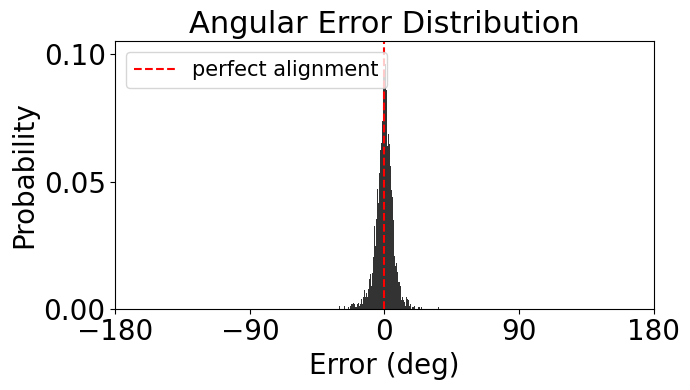

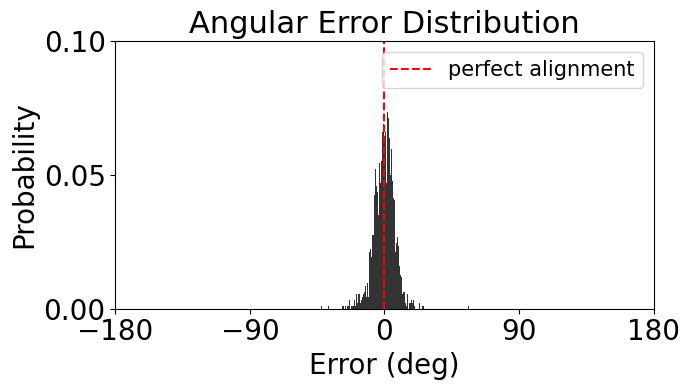

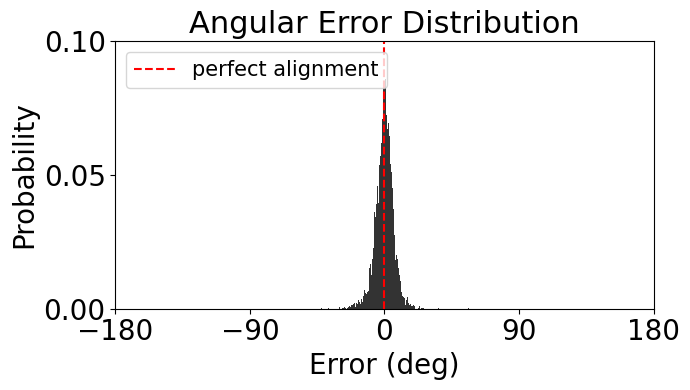

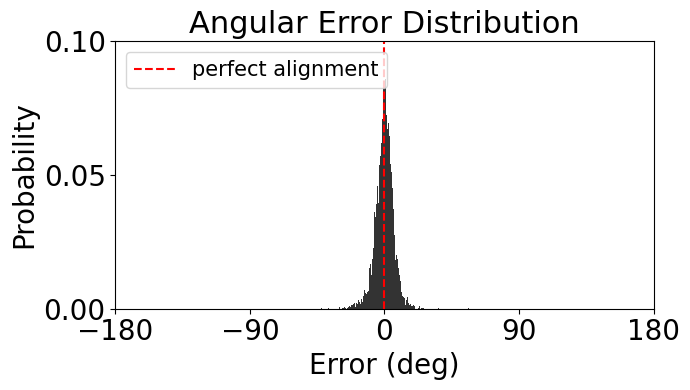

In [75]:
plot_error_histogram(paula_df, err_col="err")
plot_error_histogram(rex_df, err_col="err")

merged_combined = pd.concat([paula_df, rex_df], axis=0, ignore_index=True)
merged_combined

plot_error_histogram(merged_combined, err_col="err")

In [40]:
# import pickle

# with open('/home/aarghavan/aslan/data/paula_behavior_all.pkl', 'wb') as f:
#                 pickle.dump(paula_df, f)

# with open('/home/aarghavan/aslan/data/rex_behavior_all.pkl', 'wb') as f:
#                 pickle.dump(rex_df, f)


In [41]:
# plot_error_histogram(paula_df, err_col="err")
# plot_error_histogram(rex_df, err_col="err")

In [42]:
combined_df = pd.concat([paula_df, rex_df], axis=0, ignore_index=True)
combined_df

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,memoryDelay,curr,resp,prev,diff_signed,diff_abs,err,folded_err,diff,abs_err
0,100706,2,10218.32,-6506.60,7323.571429,-6579.285714,7078.318084,-6412.870771,296.383428,2,...,0.749975,0.0,4.205191,NaN,NaN,NaN,-4.205191,4.205191,NaN,4.205191
1,100706,3,10188.56,-6520.56,13730.428571,-6740.809524,13328.561916,-6614.289229,421.312466,3,...,0.750025,180.0,177.528674,0.0,-180.0,180.0,2.471326,-2.471326,180.0,2.471326
2,100706,4,10190.00,-6554.28,11380.904762,-8739.285714,11706.865295,-8635.116206,342.201046,4,...,0.750025,120.0,113.474123,180.0,-60.0,60.0,6.525877,-6.525877,60.0,6.525877
3,100706,5,10175.68,-6522.44,11400.333333,-8611.190476,11692.545295,-8603.276206,292.319117,5,...,0.750000,120.0,114.996894,120.0,0.0,0.0,5.003106,5.003106,0.0,5.003106
4,100706,9,10188.56,-6470.00,9282.190476,-8934.571429,8565.423379,-8457.106976,861.235957,9,...,0.750000,60.0,75.815104,120.0,-60.0,60.0,-15.815104,15.815104,60.0,15.815104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7542,110220,1407,2651.16,-15878.88,-783.272727,-15824.818182,775.890518,-17254.224579,2115.228752,1407,...,0.750000,60.0,3.817668,120.0,-60.0,60.0,56.182332,-56.182332,60.0,56.182332
7543,110220,1408,1494.12,-15190.60,-373.333333,-14651.761905,270.686629,-13653.892220,1187.647094,1408,...,0.750025,-60.0,-22.263415,60.0,-120.0,120.0,-37.736585,37.736585,120.0,37.736585
7544,110220,1413,1599.04,-15295.40,3359.666667,-13911.333333,3474.309482,-13920.055421,114.974127,1413,...,0.750025,-120.0,-118.075739,-60.0,-60.0,60.0,-1.924261,1.924261,60.0,1.924261
7545,110220,1414,1165.92,-15291.48,-1706.095238,-15181.904762,-1932.782853,-15130.116799,232.527993,1414,...,0.750000,0.0,1.457369,-120.0,120.0,120.0,-1.457369,-1.457369,120.0,1.457369


In [43]:
# with open('/home/aarghavan/aslan/data/response_all.pkl', 'wb') as f:
#                 pickle.dump(combined_df, f)

In [44]:
# combined_df.to_csv("behavior_all.csv", index=False)

# Calculate ITI and filter data based on it

In [45]:
paula_df.sort_values(by=['session_id', 'trial'], inplace=True)
rex_df.sort_values(by=['session_id', 'trial'], inplace=True)

(array([3.328e+03, 0.000e+00, 8.730e+02, 0.000e+00, 3.570e+02, 0.000e+00,
        1.540e+02, 0.000e+00, 6.900e+01, 0.000e+00, 3.500e+01, 0.000e+00,
        2.600e+01, 0.000e+00, 1.300e+01, 0.000e+00, 6.000e+00, 0.000e+00,
        5.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        4.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 4.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

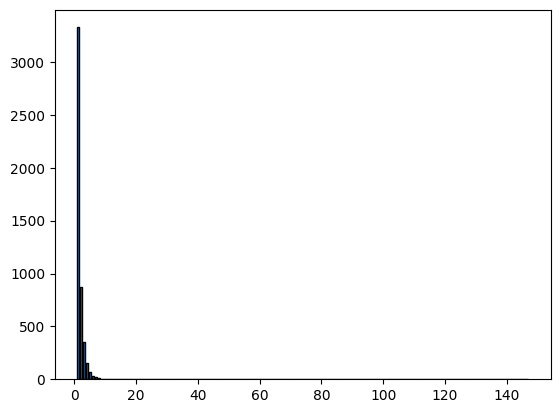

In [46]:
session_diff = paula_df.groupby('session_id')['trial'].diff()
plt.hist(session_diff.dropna(), bins=300, edgecolor='black')

In [47]:
paula_df['trial_ends'] = paula_df['responseDone'] + paula_df['trialRefTimes']
paula_df['trial_starts'] = paula_df['fixptOn'] + paula_df['trialRefTimes']

paula_df['ITI'] = paula_df.groupby('session_id')['trial_starts'].shift(-1) - paula_df['trial_ends']

In [48]:
rex_df['trial_ends'] = rex_df['responseDone'] + rex_df['trialRefTimes']
rex_df['trial_starts'] = rex_df['fixptOn'] + rex_df['trialRefTimes']

rex_df['ITI'] = rex_df.groupby('session_id')['trial_starts'].shift(-1) - rex_df['trial_ends']

In [49]:
MAX_ITI_DURATION = 5


paula_df['ITI'] = pd.to_numeric(paula_df['ITI'], errors='coerce')
filtered_paula = paula_df[paula_df['ITI'] <= MAX_ITI_DURATION].copy()

print("Paula before: ", len(paula_df))
print("Paula after: ", len(filtered_paula))
print("remaining percentage: ", len(filtered_paula)/len(paula_df) * 100)


rex_df['ITI'] = pd.to_numeric(rex_df['ITI'], errors='coerce')
filtered_rex = rex_df[rex_df['ITI'] <= MAX_ITI_DURATION].copy()

print("Rex before: ", len(rex_df))
print("Rex after: ",len(filtered_rex))
print("remaining percentage: ", len(filtered_rex)/len(rex_df) * 100)

print("remaining percentage for both subjects: ", (len(filtered_paula)+len(filtered_rex))/(len(paula_df)+len(rex_df)) * 100)


Paula before:  4940
Paula after:  3322
remaining percentage:  67.24696356275304
Rex before:  2607
Rex after:  1247
remaining percentage:  47.83275795934024
remaining percentage for both subjects:  60.54061216377369


In [50]:
filtered_paula

,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,prev,diff_signed,diff_abs,err,folded_err,diff,abs_err,trial_ends,trial_starts,ITI
0,100706,2,10218.32,-6506.60,7323.571429,-6579.285714,7078.318084,-6412.870771,296.383428,2,...,NaN,NaN,NaN,-4.205191,4.205191,NaN,4.205191,44.49485,40.521,3.865900
1,100706,3,10188.56,-6520.56,13730.428571,-6740.809524,13328.561916,-6614.289229,421.312466,3,...,0.0,-180.0,180.0,2.471326,-2.471326,180.0,2.471326,52.470375,48.36075,3.640150
2,100706,4,10190.00,-6554.28,11380.904762,-8739.285714,11706.865295,-8635.116206,342.201046,4,...,180.0,-60.0,60.0,6.525877,-6.525877,60.0,6.525877,60.018175,56.110525,3.652175
4,100706,9,10188.56,-6470.00,9282.190476,-8934.571429,8565.423379,-8457.106976,861.235957,9,...,120.0,-60.0,60.0,-15.815104,15.815104,60.0,15.815104,111.704975,107.65905,3.423850
5,100706,10,10238.92,-6615.28,12166.761905,-4585.476190,11862.056621,-4628.173024,307.682189,10,...,60.0,-180.0,180.0,3.893664,-3.893664,180.0,3.893664,119.629275,115.128825,3.599350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,110117_02,285,2263.24,-3749.48,3883.952381,-2099.238095,3707.474211,-2013.551614,196.180319,285,...,-120.0,0.0,0.0,3.970459,3.970459,0.0,3.970459,2336.4629,2333.110475,2.747425
4932,110117_02,286,2314.80,-4152.60,3668.666667,-6033.904762,4015.314144,-5864.988962,385.612527,286,...,-120.0,-120.0,120.0,7.885458,-7.885458,120.0,7.885458,2342.531325,2339.210325,2.738875
4933,110117_02,287,2083.80,-4103.16,-376.666667,-2383.714286,383.285856,-2390.771038,759.985286,287,...,120.0,-180.0,180.0,-10.356778,10.356778,180.0,10.356778,2348.8428,2345.2702,2.737275
4937,110117_02,302,2376.32,-4119.48,-211.571429,-2553.857143,675.805856,-2407.091038,899.432452,302,...,120.0,-180.0,180.0,-14.630587,14.630587,180.0,14.630587,2437.95825,2434.268275,2.769900


In [51]:
# filtered_rex.info()
filtered_rex['memoryDelay']

0       0.750000
2       0.750025
4       0.750000
5       0.750000
7       0.750025
          ...   
2599    0.750025
2600    0.750025
2602    0.750000
2604    0.750025
2605    0.750000
Name: memoryDelay, Length: 1247, dtype: float64

In [52]:
filtered_rex.columns

Index(['session_id', 'trial_id', 'fixBaseX_raw', 'fixBaseY_raw', 'endX_raw',
       'endY_raw', 'targX_raw_pred', 'targY_raw_pred', 'endErr_raw', 'trial',
       'taskTrial', 'bhvTrial', 'condition', 'task', 'outcome', 'correct',
       'reactionTime', 'numRewards', 'mapColors', 'mapDirections', 'targetPos',
       'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2', 'stimOn',
       'stimOff', 'targetOn', 'targetOff', 'fixptOff', 'responseTime',
       'responseDone', 'holdTgtOn', 'holdTgtOff', 'responseHeld',
       'outcomeTime', 'rewardOn', 'rewardOff', 'trialEnd', 'session',
       'trialRefTimes', 'badTimingTrials', 'badTrials', 'trialStart_idx',
       'fixptOn_idx', 'fixationTime_idx', 'fixptOn2_idx', 'stimOn_idx',
       'stimOff_idx', 'targetOn_idx', 'targetOff_idx', 'fixptOff_idx',
       'responseTime_idx', 'responseDone_idx', 'holdTgtOn_idx',
       'holdTgtOff_idx', 'responseHeld_idx', 'outcomeTime_idx', 'targEcc',
       'targAng', 'targX', 'targY', 'respEcc_raw', 'respA

In [53]:
# plt.hist(paula_df['targetOn'], bins=1000, edgecolor='black')
# plt.xlabel('targetOn (s)')
# plt.ylabel('Count')
# plt.text(1.68, 100, "6 RSVP: 6 * 150 ms + 5 * 50 ms = ~ 1.2 s ", rotation=90, color='red')
# plt.text(1.69, 100, "targetOn - stimOff = ~ 0.5 s", rotation=90, color='red')
# plt.text(1.465, 100, "8 RSVP: 8 * 100 ms + 7 * 20 ms = ~ 0.96 s ", rotation=90, color='red')
# plt.text(1.475, 100, "targetOn - stimOff = ~ 0.5 s", rotation=90, color='red')
# plt.title('Paula - targetOn Time Distribution')

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

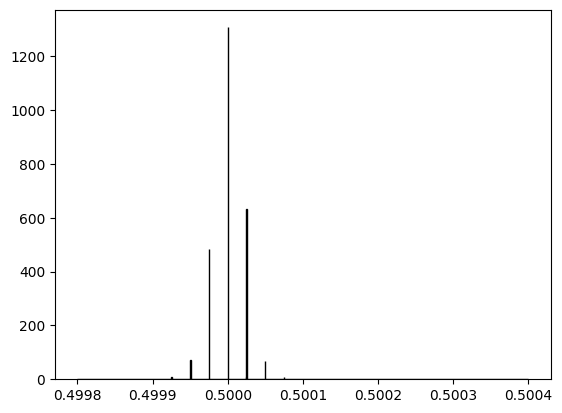

In [54]:
plt.hist(rex_df['targetOn'] - rex_df['stimOff'], bins=1000, edgecolor='black') # ~ 0.5 s

In [55]:
# Paula

# find sessions with targetOn around 1.7 s
session_list = paula_df[
    (paula_df['targetOn'] > 1.6995) & (paula_df['targetOn'] < 1.7002)
]['session_id'].unique().tolist()

print(session_list)
print(len(session_list))


# find sessions with 6 map stimuli
sessionTable[['session', 'nMapStim']]
paula_6_sess = sessionTable[
    (sessionTable['subject'] == 'paula') & (sessionTable['nMapStim'] == 6)
]['session'].unique().tolist()

print(paula_6_sess)
print(len(paula_6_sess))

# compare the two lists
common = set(session_list) & set(paula_6_sess)
only_in_session_list = set(session_list) - set(paula_6_sess)
only_in_paula_6 = set(paula_6_sess) - set(session_list)

print("In both lists:", common)
print(len(common))
print("Only in session_list:", only_in_session_list)
print("Only in paula_6_sess:", only_in_paula_6)


['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', '101128', '101202', '101206', '101207', '101209', '101210', '101216']
29
['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', '101128', '101202', '101206', '101207', '101209', '101210', '101216']
29
In both lists: {'101209', '100730', '101210', '101206', '100731', '100818', '100828', '100824', '101122', '100726', '100725', '100826', '101123', '101124', '100804', '100817', '100827', '100820', '100706', '100823', '100802', '101202', '100724', '101207', '101127', '101216', '101128', '100819', '100803'}
29
Only in session_list: set()
Only in paula_6_sess: set()


In [56]:
# Rex

# find sessions with targetOn around 1.7 s
session_list = rex_df[
    (rex_df['targetOn'] > 1.6995) & (rex_df['targetOn'] < 1.7002)
]['session_id'].unique().tolist()

print(session_list)
print(len(session_list))


# find sessions with 6 map stimuli
sessionTable[['session', 'nMapStim']]
rex_6_sess = sessionTable[
    (sessionTable['subject'] == 'rex') & (sessionTable['nMapStim'] == 6)
]['session'].unique().tolist()

print(rex_6_sess)
print(len(rex_6_sess))

# compare the two lists
common = set(session_list) & set(rex_6_sess)
only_in_session_list = set(session_list) - set(rex_6_sess)
only_in_paula_6 = set(rex_6_sess) - set(session_list)

print("In both lists:", common)
print(len(common))
print("Only in session_list:", only_in_session_list)
print("Only in rex_6_sess:", only_in_paula_6)


['100907', '100910', '100913', '100915', '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', '110121']
16
['100907', '100910', '100913', '100915', '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', '110121']
16
In both lists: {'100910', '100917', '101027', '100913', '100920', '100907', '101009', '101024', '101028', '110121', '100921', '100915', '110120', '101030', '101023', '101008'}
16
Only in session_list: set()
Only in rex_6_sess: set()


Text(0.5, 1.0, 'Rex - targetOn Time Distribution')

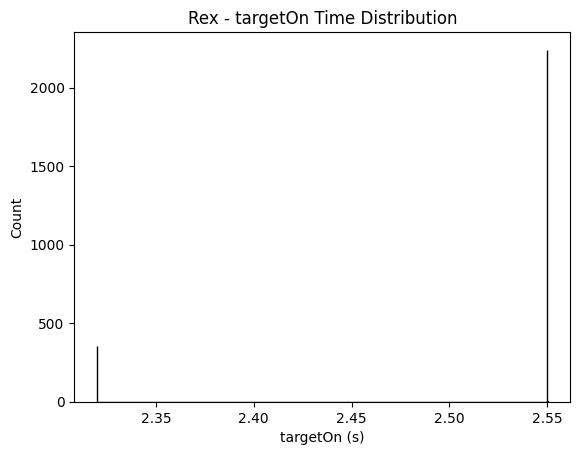

In [57]:
plt.hist(rex_df['fixptOff'], bins=1000, edgecolor='black')
plt.xlabel('targetOn (s)')
plt.ylabel('Count')
plt.title('Rex - targetOn Time Distribution')

# Redo analysis for the filtered data 

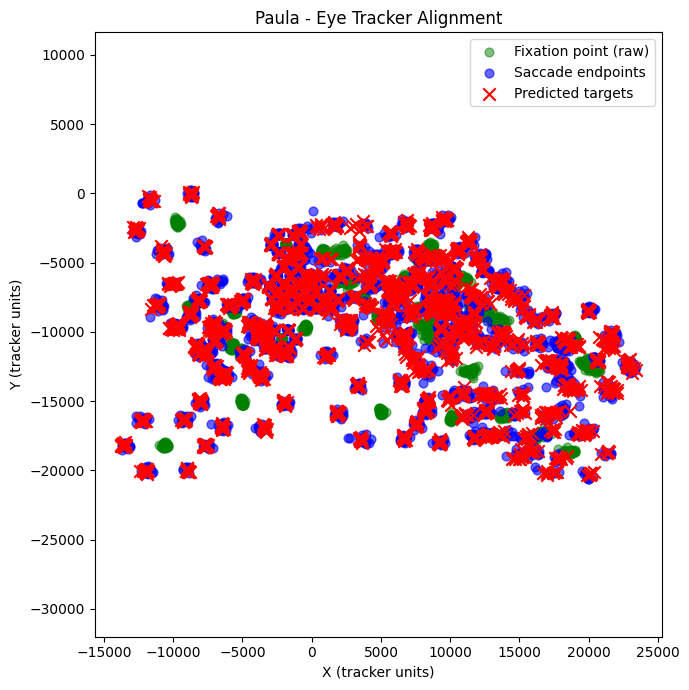

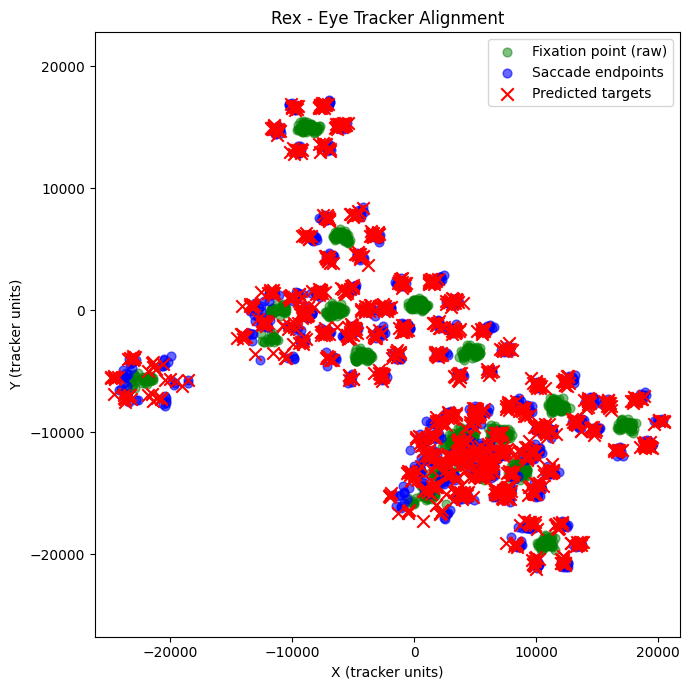

In [58]:
plot_eye_endpoints(filtered_paula, title="Paula - Eye Tracker Alignment")
plot_eye_endpoints(filtered_rex, title="Rex - Eye Tracker Alignment")


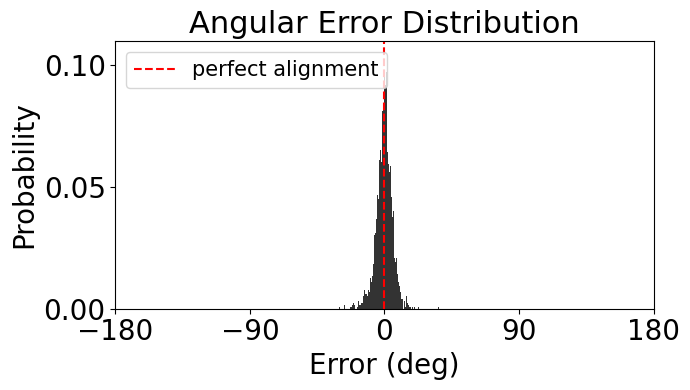

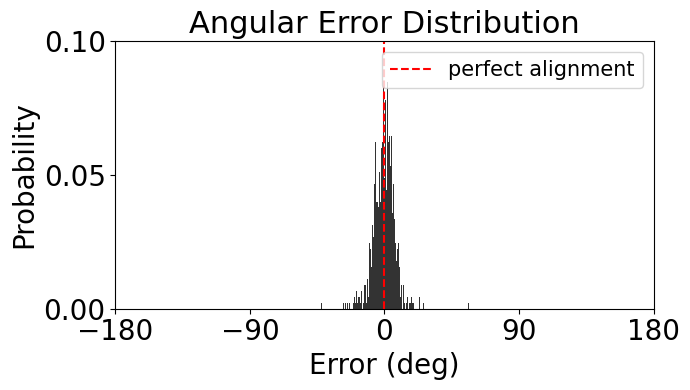

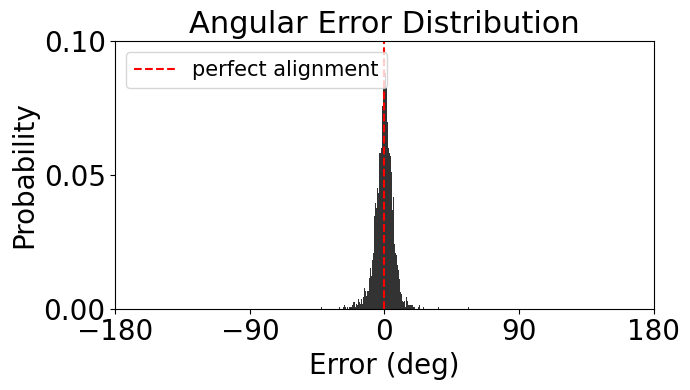

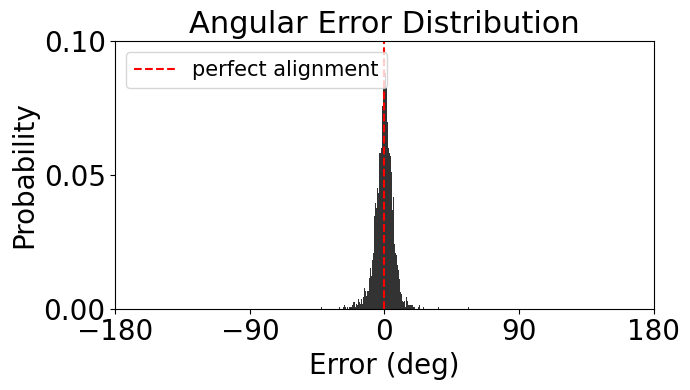

In [59]:
plot_error_histogram(filtered_paula, err_col="err")
plot_error_histogram(filtered_rex, err_col="err")

filtered_combined = pd.concat([filtered_paula, filtered_rex], axis=0, ignore_index=True)
filtered_combined

plot_error_histogram(filtered_combined, err_col="err")

In [60]:
# Convert to numeric immediately after filtering
filtered_paula['memoryDelay'] = pd.to_numeric(filtered_paula['memoryDelay'], errors='coerce')
filtered_paula['abs_err'] = pd.to_numeric(filtered_paula['abs_err'], errors='coerce')
filtered_paula['folded_err'] = pd.to_numeric(filtered_paula['folded_err'], errors='coerce')

filtered_rex['memoryDelay'] = pd.to_numeric(filtered_rex['memoryDelay'], errors='coerce')
filtered_rex['abs_err'] = pd.to_numeric(filtered_rex['abs_err'], errors='coerce')
filtered_rex['folded_err'] = pd.to_numeric(filtered_rex['folded_err'], errors='coerce')


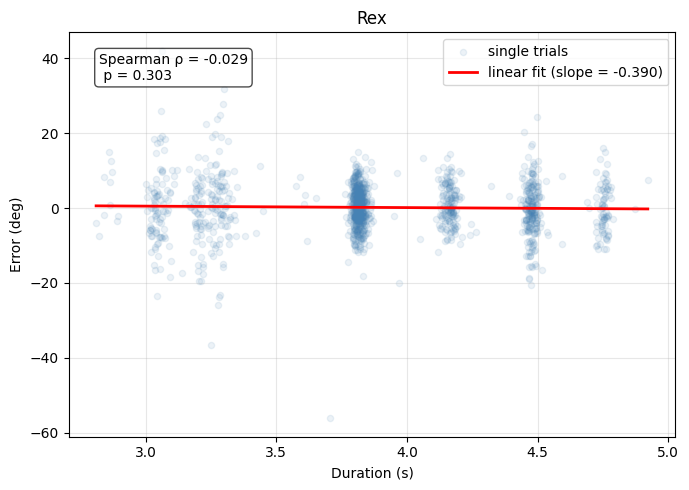

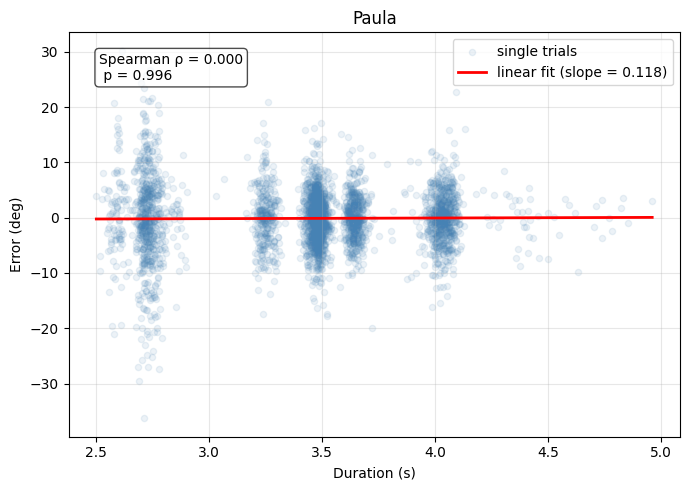

In [61]:
# Rex
plot_error_variability_vs_delay(
    filtered_rex, 
    delay_col = "ITI",
    err_col="folded_err",
    title="Rex"
)


# Paula
plot_error_variability_vs_delay(
    filtered_paula, 
    delay_col = "ITI",
    err_col="folded_err",
    title="Paula"
)

In [62]:
# def compute_binned_stats(df, n_bins=10):
#     df = df.copy()
#     df['delay_bin'] = pd.qcut(df['memoryDelay'], q=n_bins)

#     summary = df.groupby('delay_bin', observed=True)['abs_err'].agg(['mean', 'count', 'std'])
#     summary['se'] = summary['std'] / np.sqrt(summary['count'])
#     summary['delay'] = df.groupby('delay_bin', observed=True)['memoryDelay'].mean()

#     return summary.reset_index(drop=True)



# paula_summary = compute_binned_stats(filtered_paula)
# paula_summary['subject'] = 'Paula'

# rex_summary = compute_binned_stats(filtered_rex)
# rex_summary['subject'] = 'Rex'

# combined = pd.concat([paula_summary, rex_summary])

# plt.figure(figsize=(6,4))

# for subj, subdf in combined.groupby('subject'):
#     plt.errorbar(
#         subdf['delay'],
#         subdf['mean'],
#         yerr=subdf['se'],
#         fmt='-',           # line + marker
#         capsize=0,
#         label=subj
#     )

# plt.xlabel('Delay duration (s)')
# plt.ylabel('Absolute error (°)')
# plt.ylim(0, 10)
# # plt.title('Memory precision vs. delay — Paula vs Rex')
# # plt.grid(linestyle='--')
# plt.legend(title='Subject')
# plt.tight_layout()
# plt.show()


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


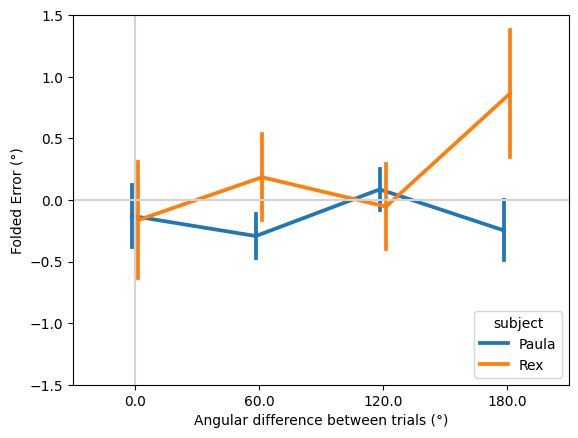

In [63]:
filtered_rex['subject'] = 'Rex'
filtered_paula['subject'] = 'Paula'

# combine
combined = pd.concat([filtered_paula, filtered_rex], ignore_index=True)

# plot
sns.pointplot(
    data=combined,
    x='diff',
    y='folded_err',
    hue='subject',
    errorbar='se',
    dodge=True,
    markers=''
)

plt.axhline(0, color='lightgray', linestyle='-')
plt.axvline(0, color='lightgray', linestyle='-') 
plt.ylabel('Folded Error (°)')
plt.xlabel('Angular difference between trials (°)')
plt.ylim(-1.5, 1.5)
plt.show()

In [64]:
print(filtered_paula['session_id'].nunique())
print(filtered_rex['session_id'].nunique())
print(filtered_paula['session_id'].nunique() + filtered_rex['session_id'].nunique())

43
20
63


So far we have filtered the data based on ITI criteria. Now we want to select only sessions where nMapStim == 6 so they have matching timings and do not need alignement. Hopefully observing some reactivations of RSVP this way. --> No reactivations observed

In [65]:
# Paula

# find sessions with targetOn around 1.7 s
session_list = paula_df[
    (paula_df['targetOn'] > 1.6995) & (paula_df['targetOn'] < 1.7002)
]['session_id'].unique().tolist()

print(session_list)
print(len(session_list))


# find sessions with 6 map stimuli
sessionTable[['session', 'nMapStim']]
paula_6_sess = sessionTable[
    (sessionTable['subject'] == 'paula') & (sessionTable['nMapStim'] == 6)
]['session'].unique().tolist()

print(paula_6_sess)
print(len(paula_6_sess))

# compare the two lists
common = set(session_list) & set(paula_6_sess)
only_in_session_list = set(session_list) - set(paula_6_sess)
only_in_paula_6 = set(paula_6_sess) - set(session_list)

print("In both lists:", common)
print(len(common))
print("Only in session_list:", only_in_session_list)
print("Only in paula_6_sess:", only_in_paula_6)


['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', '101128', '101202', '101206', '101207', '101209', '101210', '101216']
29
['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', '101128', '101202', '101206', '101207', '101209', '101210', '101216']
29
In both lists: {'101209', '100730', '101210', '101206', '100731', '100818', '100828', '100824', '101122', '100726', '100725', '100826', '101123', '101124', '100804', '100817', '100827', '100820', '100706', '100823', '100802', '101202', '100724', '101207', '101127', '101216', '101128', '100819', '100803'}
29
Only in session_list: set()
Only in paula_6_sess: set()


In [66]:
# Rex

# find sessions with targetOn around 1.7 s
session_list = rex_df[
    (rex_df['targetOn'] > 1.6995) & (rex_df['targetOn'] < 1.7002)
]['session_id'].unique().tolist()

print(session_list)
print(len(session_list))


# find sessions with 6 map stimuli
sessionTable[['session', 'nMapStim']]
rex_6_sess = sessionTable[
    (sessionTable['subject'] == 'rex') & (sessionTable['nMapStim'] == 6)
]['session'].unique().tolist()

print(rex_6_sess)
print(len(rex_6_sess))

# compare the two lists
common = set(session_list) & set(rex_6_sess)
only_in_session_list = set(session_list) - set(rex_6_sess)
only_in_paula_6 = set(rex_6_sess) - set(session_list)

print("In both lists:", common)
print(len(common))
print("Only in session_list:", only_in_session_list)
print("Only in rex_6_sess:", only_in_paula_6)


['100907', '100910', '100913', '100915', '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', '110121']
16
['100907', '100910', '100913', '100915', '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', '110121']
16
In both lists: {'100910', '100917', '101027', '100913', '100920', '100907', '101009', '101024', '101028', '110121', '100921', '100915', '110120', '101030', '101023', '101008'}
16
Only in session_list: set()
Only in rex_6_sess: set()


In [67]:
# select these sessions 'nMapStim' == 6

# ['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', 
#  '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', 
#  '101128', '101202', '101206', '101207', '101209', '101210', '101216', '100907', '100910', '100913', '100915', 
#  '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', 
#  '110121']

# behavioral error across t 

In [68]:
# df = pd.read_csv('/home/aarghavan/aslan/data/behavior_nMapStim_6.csv')
# df[['session_id','trial','err']]

In [71]:
print(combined['session_id'].nunique())
combined

63


,session_id,trial_id,fixBaseX_raw,fixBaseY_raw,endX_raw,endY_raw,targX_raw_pred,targY_raw_pred,endErr_raw,trial,...,diff_signed,diff_abs,err,folded_err,diff,abs_err,trial_ends,trial_starts,ITI,subject
0,100706,2,10218.32,-6506.60,7323.571429,-6579.285714,7078.318084,-6412.870771,296.383428,2,...,NaN,NaN,-4.205191,4.205191,NaN,4.205191,44.49485,40.521,3.865900,Paula
1,100706,3,10188.56,-6520.56,13730.428571,-6740.809524,13328.561916,-6614.289229,421.312466,3,...,-180.0,180.0,2.471326,-2.471326,180.0,2.471326,52.470375,48.36075,3.640150,Paula
2,100706,4,10190.00,-6554.28,11380.904762,-8739.285714,11706.865295,-8635.116206,342.201046,4,...,-60.0,60.0,6.525877,-6.525877,60.0,6.525877,60.018175,56.110525,3.652175,Paula
3,100706,9,10188.56,-6470.00,9282.190476,-8934.571429,8565.423379,-8457.106976,861.235957,9,...,-60.0,60.0,-15.815104,15.815104,60.0,15.815104,111.704975,107.65905,3.423850,Paula
4,100706,10,10238.92,-6615.28,12166.761905,-4585.476190,11862.056621,-4628.173024,307.682189,10,...,-180.0,180.0,3.893664,-3.893664,180.0,3.893664,119.629275,115.128825,3.599350,Paula
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4564,110220,1403,1474.92,-14991.76,-611.272727,-15460.363636,-400.349482,-16367.104579,930.949920,1403,...,120.0,120.0,31.765634,31.765634,120.0,31.765634,11858.343825,11853.7549,3.300900,Rex
4565,110220,1404,740.80,-15140.76,3370.428571,-15377.238095,3839.502853,-15302.123201,475.050449,1404,...,120.0,120.0,3.912402,3.912402,120.0,3.912402,11865.0958,11861.644725,3.318800,Rex
4566,110220,1407,2651.16,-15878.88,-783.272727,-15824.818182,775.890518,-17254.224579,2115.228752,1407,...,-60.0,60.0,56.182332,-56.182332,60.0,56.182332,11888.257475,11883.1443,3.706600,Rex
4567,110220,1413,1599.04,-15295.40,3359.666667,-13911.333333,3474.309482,-13920.055421,114.974127,1413,...,-60.0,60.0,-1.924261,1.924261,60.0,1.924261,11933.286875,11929.753275,3.286250,Rex
